### Deatiled pipeline

In [ ]:
%load_ext autoreload
%autoreload 2
from scripts.utils.data_loader import create_configs, load_data
from scripts.utils.preprocessing import lof_outlier_removal
from scripts.utils.post_processing import save_results, compute_fold_shap, plot_shap_summary

from scipy.stats import randint, uniform, loguniform

from sklearn.preprocessing import PowerTransformer

from imblearn import FunctionSampler

from functools import partial
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import mutual_info_classif

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV, cross_validate

from xgboost import XGBClassifier

import numpy as np
import pandas as pd

In [2]:
class CorrelationBasedFeatureSelection(BaseEstimator, TransformerMixin):
    def __init__(self, intercorr_threshold=0.90, target_corr_threshold=0.25):
        self.intercorr_threshold = intercorr_threshold
        self.target_corr_threshold = target_corr_threshold
        self.to_drop_intercorrelated_ = []
        self.to_drop_target_corr_ = []
        self.to_drop_ = []
        self.selected_features_ = []

    def fit(self, X, y):
        X_df = pd.DataFrame(X) if isinstance(X, np.ndarray) else X
        y_series = pd.Series(y) if isinstance(y, np.ndarray) else y
        
        corr_matrix = X_df.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        target_corr = X_df.apply(lambda col: col.corr(y_series)).abs()
        
        drop_intercorr_set = set()
        for col in upper_tri.columns:
            for row in upper_tri.index:
                if upper_tri.loc[row, col] > self.intercorr_threshold:
                    if row not in drop_intercorr_set and col not in drop_intercorr_set:
                        if target_corr[row] >= target_corr[col]:
                            drop_intercorr_set.add(col)
                        else:
                            drop_intercorr_set.add(row)
        
        self.to_drop_intercorrelated_ = list(drop_intercorr_set)

        X_reduced = X_df.drop(columns=self.to_drop_intercorrelated_, errors='ignore')
        target_corr_reduced = target_corr.loc[X_reduced.columns]
        n_reduced = len(target_corr_reduced)
        n_keep = int(np.ceil(self.target_corr_threshold * n_reduced))

        self.selected_features_ = (
            target_corr_reduced
            .sort_values(ascending=False)
            .head(n_keep)
            .index
            .tolist()
        )

        to_drop_target_corr_ = [
            col for col in X_reduced.columns
            if col not in self.selected_features_
        ]

        self.to_drop_target_corr_ = to_drop_target_corr_
        self.to_drop_ = self.to_drop_intercorrelated_ + self.to_drop_target_corr_

        return self

    def transform(self, X):
        X_df = pd.DataFrame(X) if isinstance(X, np.ndarray) else X.copy()
        X_selected = X_df.drop(columns=self.to_drop_, errors='ignore')
        return X_selected.values if isinstance(X, np.ndarray) else X_selected

    def set_output(self, transform):
        return self

In [ ]:
# Setup experiment configurations
case_idx = -1
model_name = "XGB"
feature_selector_method = "mi_based"
n_dict = {
    "n_repeats": 3,
    "outer_splits": 4,
    "inner_splits": 4,
    "n_iter": 10,
    "outer_verbose": 20,
    "inner_verbose": 1,
    "outer_n_jobs": -1,
    "inner_n_jobs": 1
}

config = create_configs(case_idx, model_name, feature_selector_method, n_dict)
out_dir = f"../results_tests/{model_name}_{feature_selector_method}/sex={config['sexes_key']}/task={config['tasks_key']}"
config.update({"out_dir": out_dir})

# Load data
X, y, groups = load_data(config)

# Define scoring metrics
scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "average_precision": "average_precision",
    "f1": "f1"
}

# Build pipeline
yj_pt = PowerTransformer(method="yeo-johnson", standardize=True)

lof_sampler = FunctionSampler(
    func=lof_outlier_removal,
    kw_args={
        "contamination": 0.05,
        "n_neighbors": 20,
        "algorithm": "auto",
        "metric": "manhattan",
    },
    validate=False,
)

if config["feature_selector_method"] == "mi_based":
    feature_selector = SelectPercentile(score_func=partial(mutual_info_classif, n_neighbors=5, random_state=42))

elif config["feature_selector_method"] == "corr_based":
    feature_selector = CorrelationBasedFeatureSelection()

elif config["feature_selector_method"] == "rfe":
    feature_selector = RFE(estimator=RandomForestClassifier(n_estimators=25, random_state=42), step = 0.1)

smote = SMOTE(random_state=42)

clf = XGBClassifier(
    booster="gbtree",
    tree_method="hist",
    n_jobs=1,
    verbosity=3,
    random_state=42
)

steps = [
    ("yjpt", yj_pt),
    ("outlier_removal", lof_sampler),
    ("feature_selector", feature_selector),
    ("oversampling", smote),
    ("classifier", clf),
]

pipeline = ImbPipeline(steps=steps).set_output(transform="pandas")

# Param distributions for RandomizedSearchCV
param_distributions = {}
if feature_selector_method == "mi_based":
    param_distributions.update({
        "feature_selector__percentile": randint(50, 91),  # [50, 90]
    })

elif feature_selector_method == "corr_based":
    param_distributions.update({
        "feature_selector__intercorr_threshold": uniform(0.85, 0.1),  # [0.85, 0.95]
        "feature_selector__target_corr_threshold": uniform(0.2, 0.1),  # [0.2, 0.3]
    })

elif feature_selector_method == "rfe":
    param_distributions.update({
        "feature_selector__n_features_to_select": uniform(0.1, 0.9),  # [0.1, 1.0]
    })

param_distributions.update({
    "oversampling__k_neighbors": randint(3, 8),  # [3, 7]
    "classifier__n_estimators": randint(200, 1001),  # [200, 1000]
    "classifier__learning_rate": loguniform(1e-3, 3e-1),  # [0.001, 0.3]
    "classifier__min_child_weight": uniform(1, 7),  # [1, 8]
    "classifier__max_depth": randint(1, 10),  # [1, 9]
    "classifier__gamma": uniform(0, 1),  # [0, 1]
    "classifier__subsample": uniform(0.6, 0.4),  # [0.6, 1.0]
    "classifier__colsample_bytree": uniform(0.6, 0.4),  # [0.6, 1.0]
    "classifier__reg_lambda": loguniform(1e-3, 1e1),  # [0.001, 10]
})

# Setup cross-validation
outer_splits = []
for i in range(config["n_repeats"]):
    sgkf = StratifiedGroupKFold(
        n_splits=config["outer_splits"],
        shuffle=True,
        random_state=42+i
    )
    outer_splits.extend(list(sgkf.split(X, y, groups)))

inner_cv = StratifiedGroupKFold(
    n_splits=config["inner_splits"],
    shuffle=True,
    random_state=42
)

# Setup hyperparameter tuning
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=config["n_iter"],
    scoring="roc_auc",
    n_jobs=config["inner_n_jobs"],
    cv=inner_cv,
    verbose=config["inner_verbose"],
    random_state=42,
    refit=True,
    error_score='raise'
)

# Execute nested cross-validation
results = cross_validate(
    search,
    X=X,
    y=y,
    params={'groups': groups},
    cv=outer_splits,
    scoring=scoring,
    return_estimator=True,
    n_jobs=config["outer_n_jobs"],
    verbose=config["outer_verbose"],
    error_score='raise'
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 128 concurrent workers.


[CV] START .....................................................................
Fitting 4 folds for each of 10 candidates, totalling 40 fits
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
Fitting 4 folds for each of 10 candidates, totalling 40 fits
Fitting 4 folds for each of 10 candidates, totalling 40 fits
Fitting 4 folds for each of 10 candidates, totalling 40 fits
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
Fitting 4 folds for each of 10 candidates, totalling 40 fits
[CV] START ....................................

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  2.1min


[16:33:56] ======== Monitor (0): GBTree ========
[16:33:56] BoostNewTrees: 0.226517s, 661 calls @ 226517us

[16:33:56] CommitModel: 7.5e-05s, 661 calls @ 75us

[16:33:56] ======== Monitor (0): HistUpdater ========
[16:33:56] EvaluateSplits: 0.13555s, 661 calls @ 135550us

[16:33:56] InitData: 0.003329s, 661 calls @ 3329us

[16:33:56] InitRoot: 0.209456s, 661 calls @ 209456us

[16:33:56] LeafPartition: 7.8e-05s, 661 calls @ 78us

[16:33:56] UpdatePosition: 0.005118s, 661 calls @ 5118us

[16:33:56] UpdatePredictionCache: 0.001633s, 661 calls @ 1633us

[16:33:56] UpdateTree: 0.219201s, 661 calls @ 219201us

[16:33:56] ======== Monitor (0):  ========
[16:33:56] BuildHist: 0.071476s, 661 calls @ 71476us

[16:33:56] DEBUG: /workspace/src/gbm/gbtree.cc:127: Using tree method: 3
[16:33:56] ======== Monitor (0): GBTree ========
[16:33:56] BoostNewTrees: 0.228252s, 661 calls @ 228252us

[16:33:56] CommitModel: 8.4e-05s, 661 calls @ 84us

[16:33:56] ======== Monitor (0): HistUpdater ========
[16:

[Parallel(n_jobs=-1)]: Done   2 out of  12 | elapsed:  2.2min remaining: 10.9min


...

[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:  2.2min remaining:  1.6min
[Parallel(n_jobs=-1)]: Done   8 out of  12 | elapsed:  2.2min remaining:  1.1min
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:  2.2min remaining:   44.9s


[16:34:02] ======== Monitor (0): GBTree ========
[16:34:02] BoostNewTrees: 0.557232s, 443 calls @ 557232us

[16:34:02] CommitModel: 6.3e-05s, 443 calls @ 63us

[16:34:02] ======== Monitor (0): HistUpdater ========
[16:34:02] BuildHistogram: 0.053245s, 886 calls @ 53245us

[16:34:02] EvaluateSplits: 0.414885s, 1329 calls @ 414885us

[16:34:02] InitData: 0.002274s, 443 calls @ 2274us

[16:34:02] InitRoot: 0.128044s, 443 calls @ 128044us

[16:34:02] LeafPartition: 4.7e-05s, 443 calls @ 47us

[16:34:02] UpdatePosition: 0.015392s, 1329 calls @ 15392us

[16:34:02] UpdatePredictionCache: 0.001429s, 443 calls @ 1429us

[16:34:02] UpdateTree: 0.546297s, 443 calls @ 546297us

[16:34:02] ======== Monitor (0):  ========
[16:34:02] BuildHist: 0.091947s, 1329 calls @ 91947us

[16:34:02] DEBUG: /workspace/src/gbm/gbtree.cc:127: Using tree method: 3
[CV] END  average_precision: (test=0.439) balanced_accuracy: (test=0.558) f1: (test=0.476) roc_auc: (test=0.581) total time= 2.2min
[16:34:02] ======== Mo

[Parallel(n_jobs=-1)]: Done  10 out of  12 | elapsed:  2.2min remaining:   27.0s


[16:34:02] ======== Monitor (0): GBTree ========
[16:34:02] BoostNewTrees: 0.224308s, 661 calls @ 224308us

[16:34:02] CommitModel: 7.8e-05s, 661 calls @ 78us

[16:34:02] ======== Monitor (0): HistUpdater ========
[16:34:02] EvaluateSplits: 0.1354s, 661 calls @ 135400us

[16:34:02] InitData: 0.00314s, 661 calls @ 3140us

[16:34:02] InitRoot: 0.207428s, 661 calls @ 207428us

[16:34:02] LeafPartition: 5.9e-05s, 661 calls @ 59us

[16:34:02] UpdatePosition: 0.005134s, 661 calls @ 5134us

[16:34:02] UpdatePredictionCache: 0.00162s, 661 calls @ 1620us

[16:34:02] UpdateTree: 0.216966s, 661 calls @ 216966us

[16:34:02] ======== Monitor (0):  ========
[16:34:02] BuildHist: 0.069648s, 661 calls @ 69648us

[16:34:02] DEBUG: /workspace/src/gbm/gbtree.cc:127: Using tree method: 3
[16:34:03] ======== Monitor (0): HostSketchContainer ========
[16:34:03] AllReduce: 0.005103s, 1 calls @ 5103us

[16:34:03] MakeCuts: 0.00535s, 1 calls @ 5350us

[16:34:03] INFO: /workspace/src/data/iterative_dmatrix.cc:5

[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:  2.3min remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:  2.3min finished


In [4]:
# DataFrame of results with best parameters
results_df = pd.DataFrame(results).drop(columns=["estimator"])
params_df = pd.DataFrame.from_records(est.best_params_ for est in results["estimator"])
if config["model_name"] == "GB":
    params_df["classifier__n_estimators"] = [
        est.best_estimator_.named_steps["classifier"].n_estimators_ for est in results["estimator"]
    ]
results_df = pd.concat([results_df.reset_index(drop=True), params_df.reset_index(drop=True)], axis=1)
results_df = results_df.sort_values("test_roc_auc", ascending=False)
# results_df.to_csv(f"{out_dir}/results.csv", index=False)

# Summary statistics of metrics
scoring_statistics_df = pd.DataFrame({
    k: results[f"test_{v}"] for k, v in scoring.items()
}).agg(["mean", "std"]).T
# scoring_statistics_df.to_csv(f"{out_dir}/scoring_statistics.csv", index=True)

# Outer CV results
n_outer = config["outer_splits"]
n_total = config["outer_splits"] * config["n_repeats"]
outer_df = pd.DataFrame({
    "repeat": (np.arange(n_total) // n_outer) + 1,
    "outer_fold": (np.arange(n_total) % n_outer) + 1,
    **{k: results[f"test_{v}"] for k, v in scoring.items()}
})
# outer_df.to_csv(f"{out_dir}/outer_cv_results.csv", index=False)

if feature_selector_method == "corr_based":
    inner_df = pd.DataFrame([
        {
            "repeat": (i // config["outer_splits"]) + 1,
            "outer_fold": (i % config["outer_splits"]) + 1,
            "inner_best_score": est.best_score_,
            "inner_best_params": est.best_params_,
            "selected_features": list(est.best_estimator_.named_steps["feature_selector"].selected_features_),
            "n_selected_features": len(list(est.best_estimator_.named_steps["feature_selector"].selected_features_))
        }
        for i, est in enumerate(results["estimator"])
    ])
else:
    inner_df = pd.DataFrame([
        {
            "repeat": (i // config["outer_splits"]) + 1,
            "outer_fold": (i % config["outer_splits"]) + 1,
            "inner_best_score": est.best_score_,
            "inner_best_params": est.best_params_,
            "selected_features": list(est.best_estimator_.named_steps["feature_selector"].get_feature_names_out()),
            "n_selected_features": len(list(est.best_estimator_.named_steps["feature_selector"].get_feature_names_out()))
        }
        for i, est in enumerate(results["estimator"])
    ])
# inner_df.to_csv(f"{out_dir}/inner_cv_results.csv", index=False)

In [5]:
all_shap_dfs, total_shap_df, shap_df_avg = compute_fold_shap(outer_splits, results, model_name, X, y, config)

100%|===================| 658/659 [00:35<00:00]        

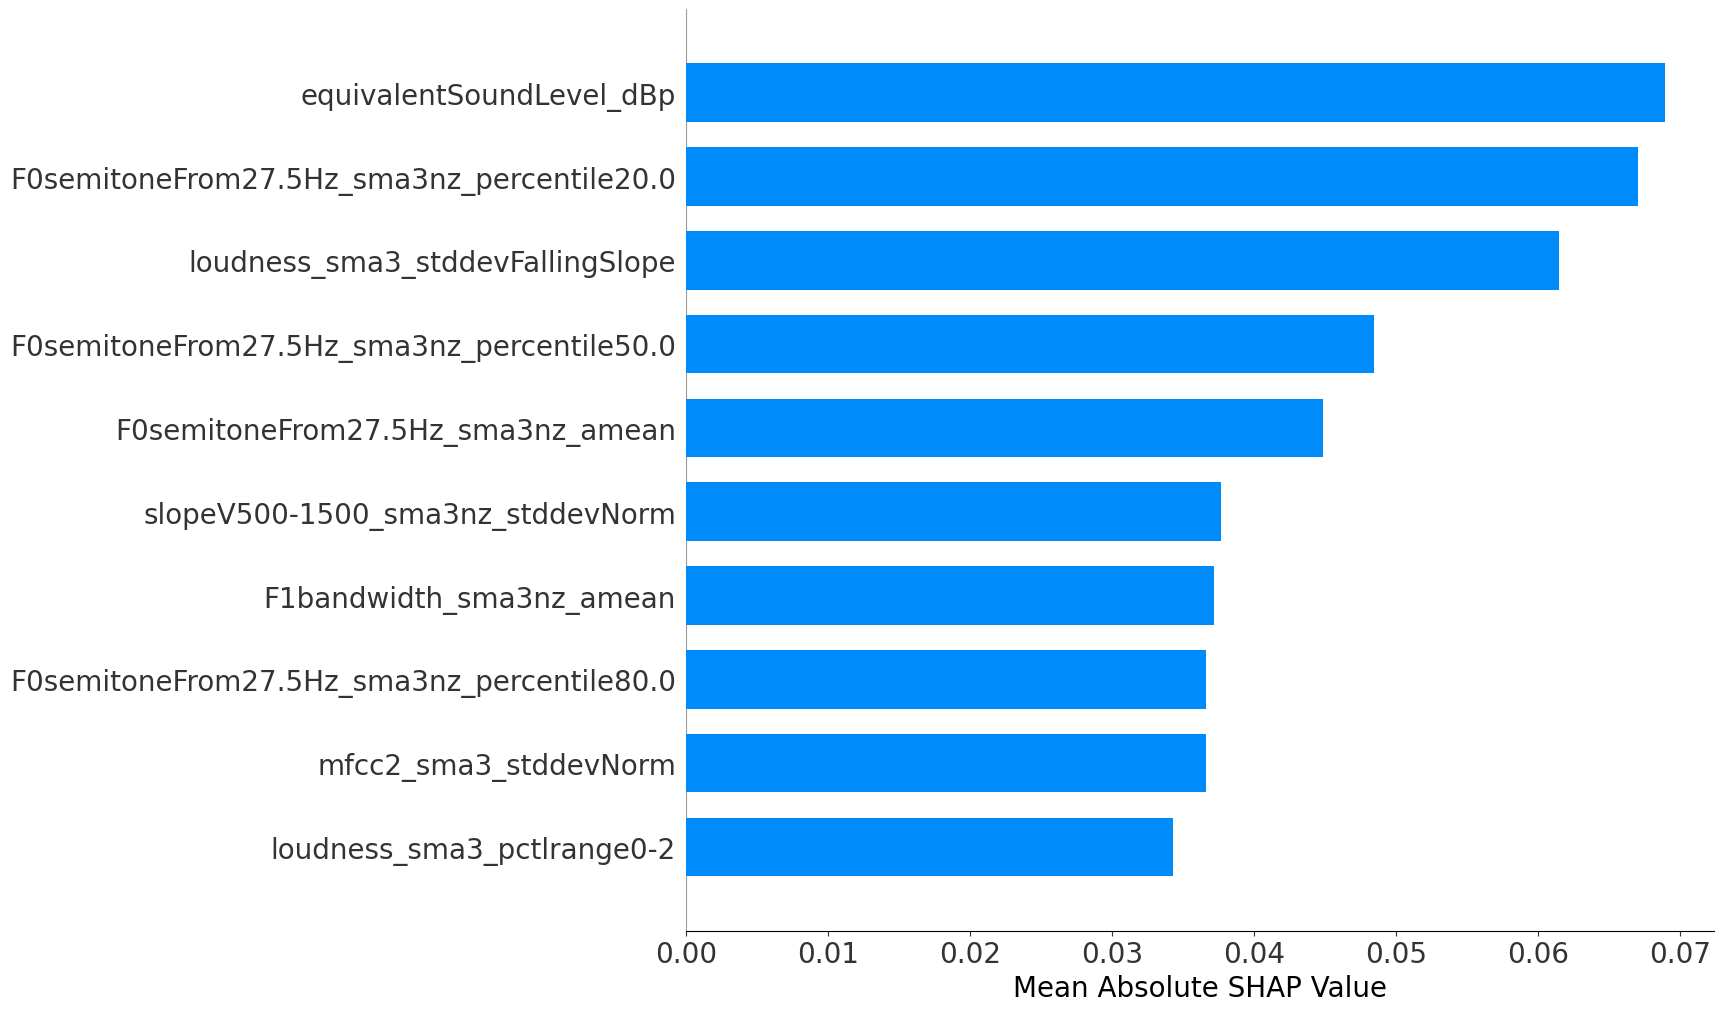

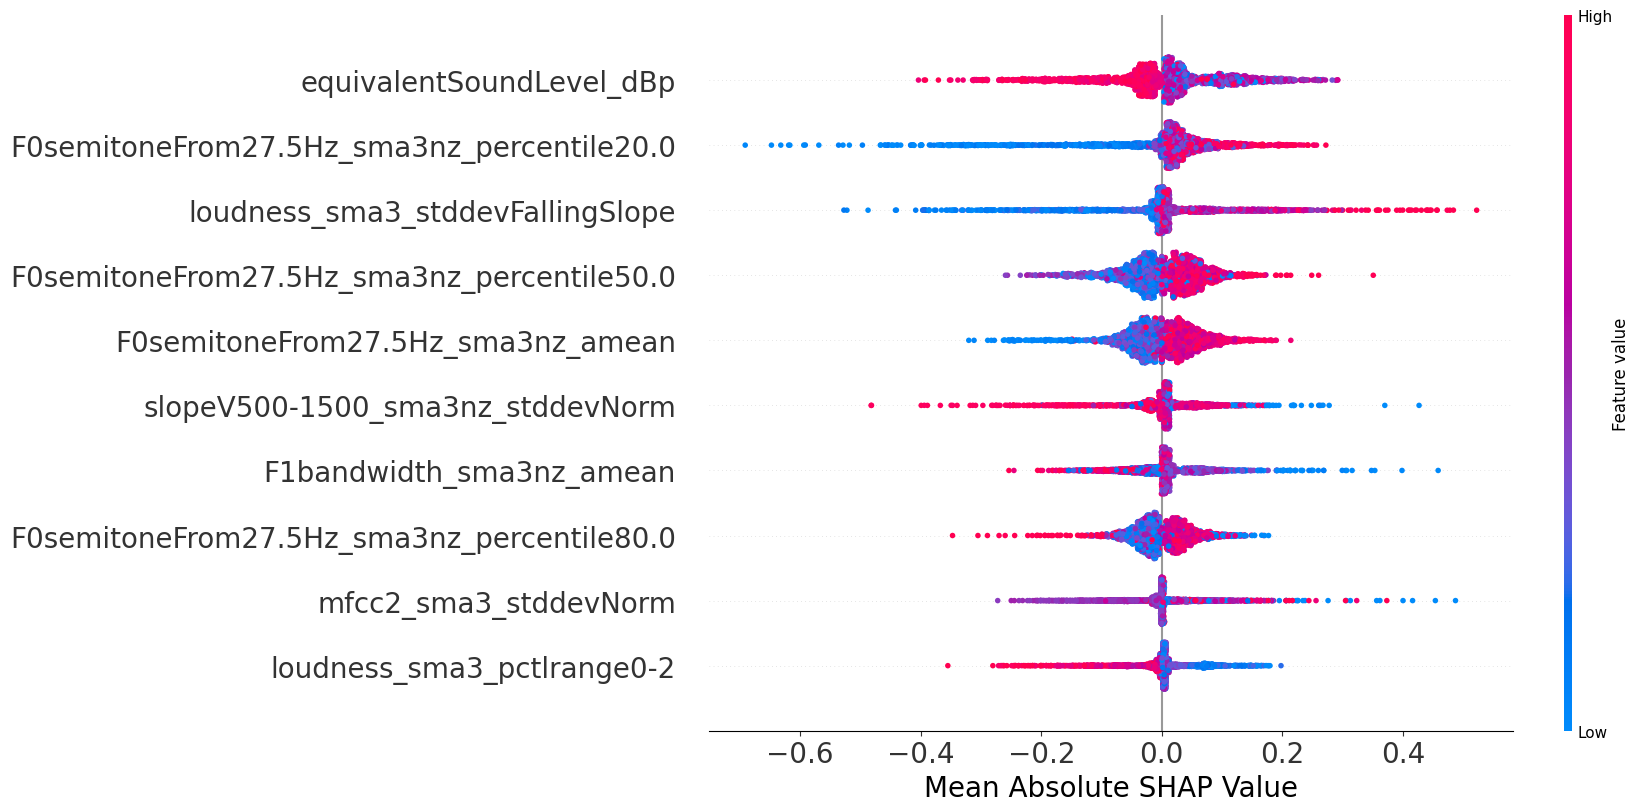

In [6]:
plot_shap_summary(shap_df_avg, X, config)

### High-level pipeline

In [8]:
%load_ext autoreload
%autoreload 2

from scripts.utils.data_loader import create_configs
from scripts.utils.train_tune_val import run_experiment

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 128 concurrent workers.


[CV] START .....................................................................
Fitting 4 folds for each of 10 candidates, totalling 40 fits
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
Fitting 4 folds for each of 10 candidates, totalling 40 fits
Fitting 4 folds for each of 10 candidates, totalling 40 fits
[CV] START .....................................................................
Fitting 4 folds for each of 10 candidates, totalling 40 fits
Fitting 4 folds for each of 10 candidates, totalling 40 fits
[CV] START .....................................................................
Fitting 4 folds for each of 10 candidates, totalling 40 fits
[CV] START .....................................................................
Fitting 4 folds for each of 10 candidates, totalling 40 fits
[CV] S

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  2.6min


[17:13:20] ======== Monitor (0): GBTree ========
[17:13:20] BoostNewTrees: 0.448713s, 661 calls @ 448713us

[17:13:20] CommitModel: 0.000118s, 661 calls @ 118us

[17:13:20] ======== Monitor (0): HistUpdater ========
[17:13:20] BuildHistogram: 0.031553s, 1322 calls @ 31553us

[17:13:20] EvaluateSplits: 0.348479s, 1983 calls @ 348479us

[17:13:20] InitData: 0.002903s, 661 calls @ 2903us

[17:13:20] InitRoot: 0.09888s, 661 calls @ 98880us

[17:13:20] LeafPartition: 8.3e-05s, 661 calls @ 83us

[17:13:20] UpdatePosition: 0.016469s, 1983 calls @ 16469us

[17:13:20] UpdatePredictionCache: 0.001919s, 661 calls @ 1919us

[17:13:20] UpdateTree: 0.440795s, 661 calls @ 440795us

[17:13:20] ======== Monitor (0):  ========
[17:13:20] BuildHist: 0.052966s, 1983 calls @ 52966us

[17:13:20] DEBUG: /workspace/src/gbm/gbtree.cc:127: Using tree method: 3
[17:13:20] ======== Monitor (0): HostSketchContainer ========
[17:13:20] AllReduce: 0.00265s, 1 calls @ 2650us

[17:13:20] MakeCuts: 0.002751s, 1 calls @

[Parallel(n_jobs=-1)]: Done   2 out of  12 | elapsed:  2.6min remaining: 12.9min
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:  2.6min remaining:  7.7min


...

[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:  2.6min remaining:   52.7s


[17:13:24] ======== Monitor (0): GBTree ========
[17:13:24] BoostNewTrees: 0.594544s, 443 calls @ 594544us

[17:13:24] CommitModel: 8.5e-05s, 443 calls @ 85us

[17:13:24] ======== Monitor (0): HistUpdater ========
[17:13:24] BuildHistogram: 0.062434s, 886 calls @ 62434us

[17:13:24] EvaluateSplits: 0.433521s, 1329 calls @ 433521us

[17:13:24] InitData: 0.002437s, 443 calls @ 2437us

[17:13:24] InitRoot: 0.140081s, 443 calls @ 140081us

[17:13:24] LeafPartition: 5.3e-05s, 443 calls @ 53us

[17:13:24] UpdatePosition: 0.015454s, 1329 calls @ 15454us

[17:13:24] UpdatePredictionCache: 0.001475s, 443 calls @ 1475us

[17:13:24] UpdateTree: 0.583326s, 443 calls @ 583326us

[17:13:24] ======== Monitor (0):  ========
[17:13:24] BuildHist: 0.105922s, 1329 calls @ 105922us

[17:13:24] DEBUG: /workspace/src/gbm/gbtree.cc:127: Using tree method: 3
[CV] END  average_precision: (test=0.442) balanced_accuracy: (test=0.543) f1: (test=0.464) roc_auc: (test=0.562) total time= 2.6min


[Parallel(n_jobs=-1)]: Done  10 out of  12 | elapsed:  2.6min remaining:   31.7s


[17:13:25] ======== Monitor (0): HostSketchContainer ========
[17:13:25] AllReduce: 0.011288s, 1 calls @ 11288us

[17:13:25] MakeCuts: 0.011534s, 1 calls @ 11534us

[17:13:25] INFO: /workspace/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (2328, 69, 160632).
[17:13:25] DEBUG: /workspace/src/gbm/gbtree.cc:127: Using tree method: 3
[17:13:25] ======== Monitor (0): HostSketchContainer ========
[17:13:25] AllReduce: 0.008738s, 1 calls @ 8738us

[17:13:25] MakeCuts: 0.008959s, 1 calls @ 8959us

[17:13:25] INFO: /workspace/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (2280, 56, 127680).
[17:13:25] DEBUG: /workspace/src/gbm/gbtree.cc:127: Using tree method: 3
[17:13:26] ======== Monitor (0): GBTree ========
[17:13:26] BoostNewTrees: 0.596166s, 443 calls @ 596166us

[17:13:26] CommitModel: 8.7e-05s, 443 calls @ 87us

[17:13:26] ======== Monitor (0): HistUpdater ========
[17:13:26] BuildHistogram: 0.062394s, 886 calls @ 62394u

[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:  2.9min remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:  2.9min finished
 97%|=================== | 631/648 [00:37<00:00]       

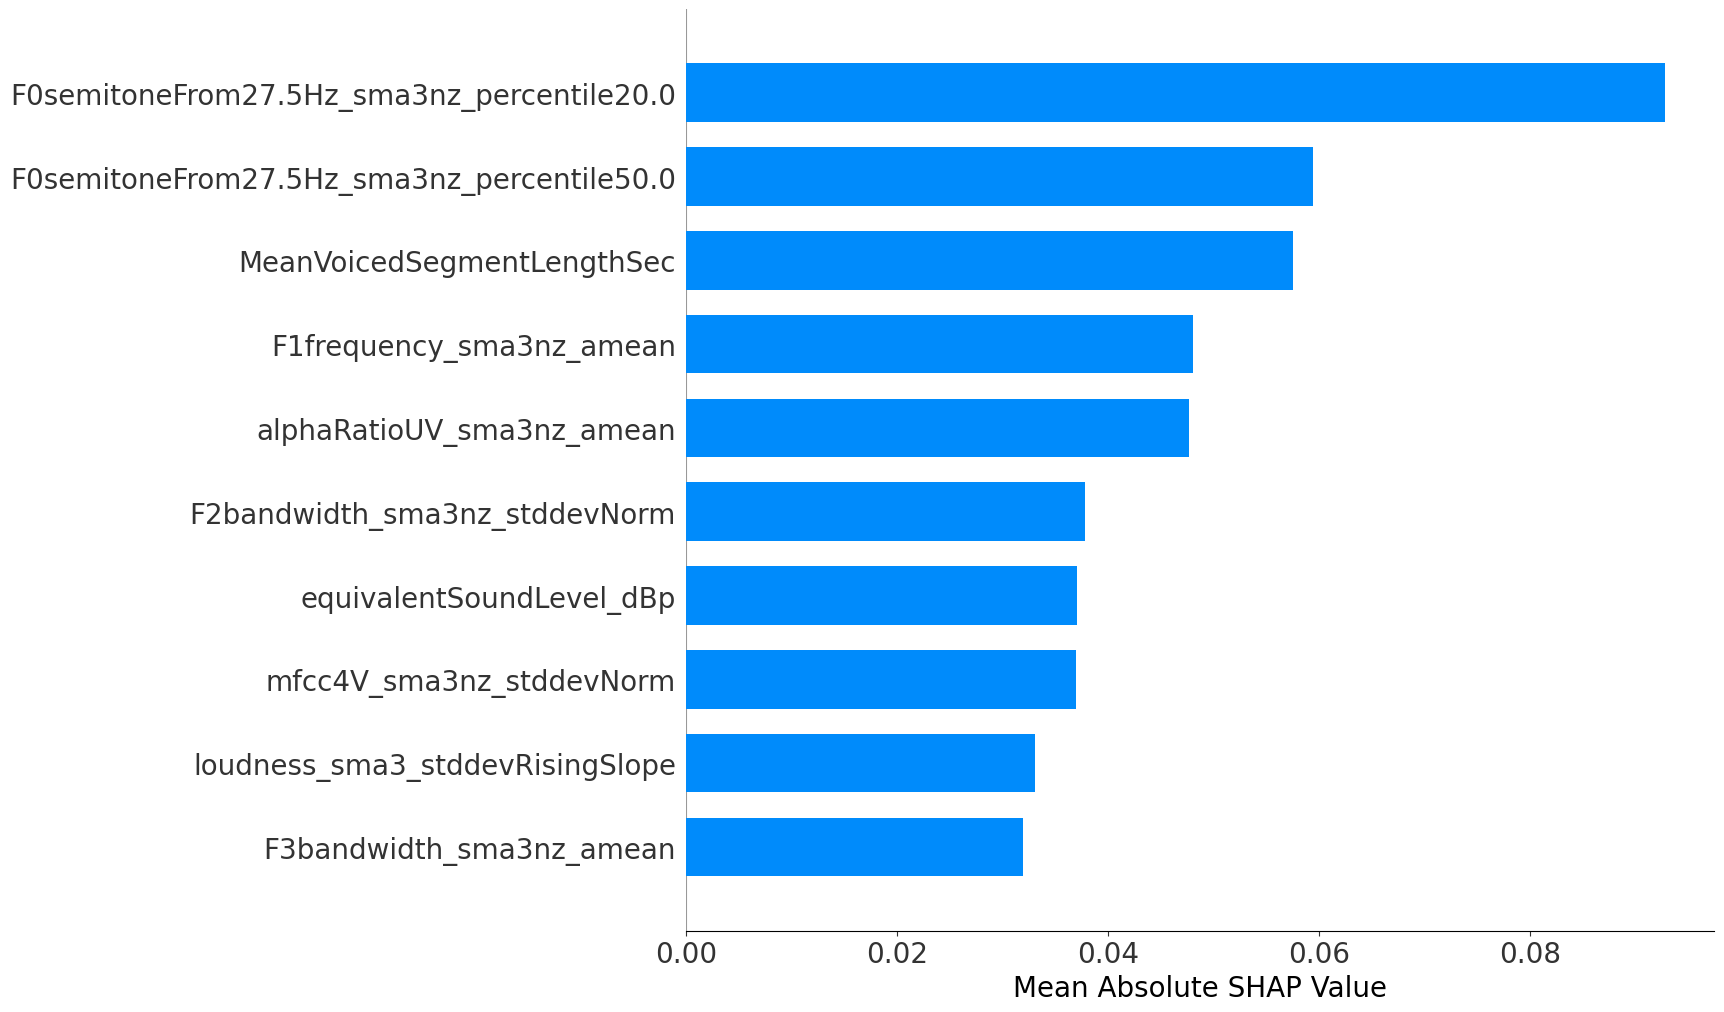

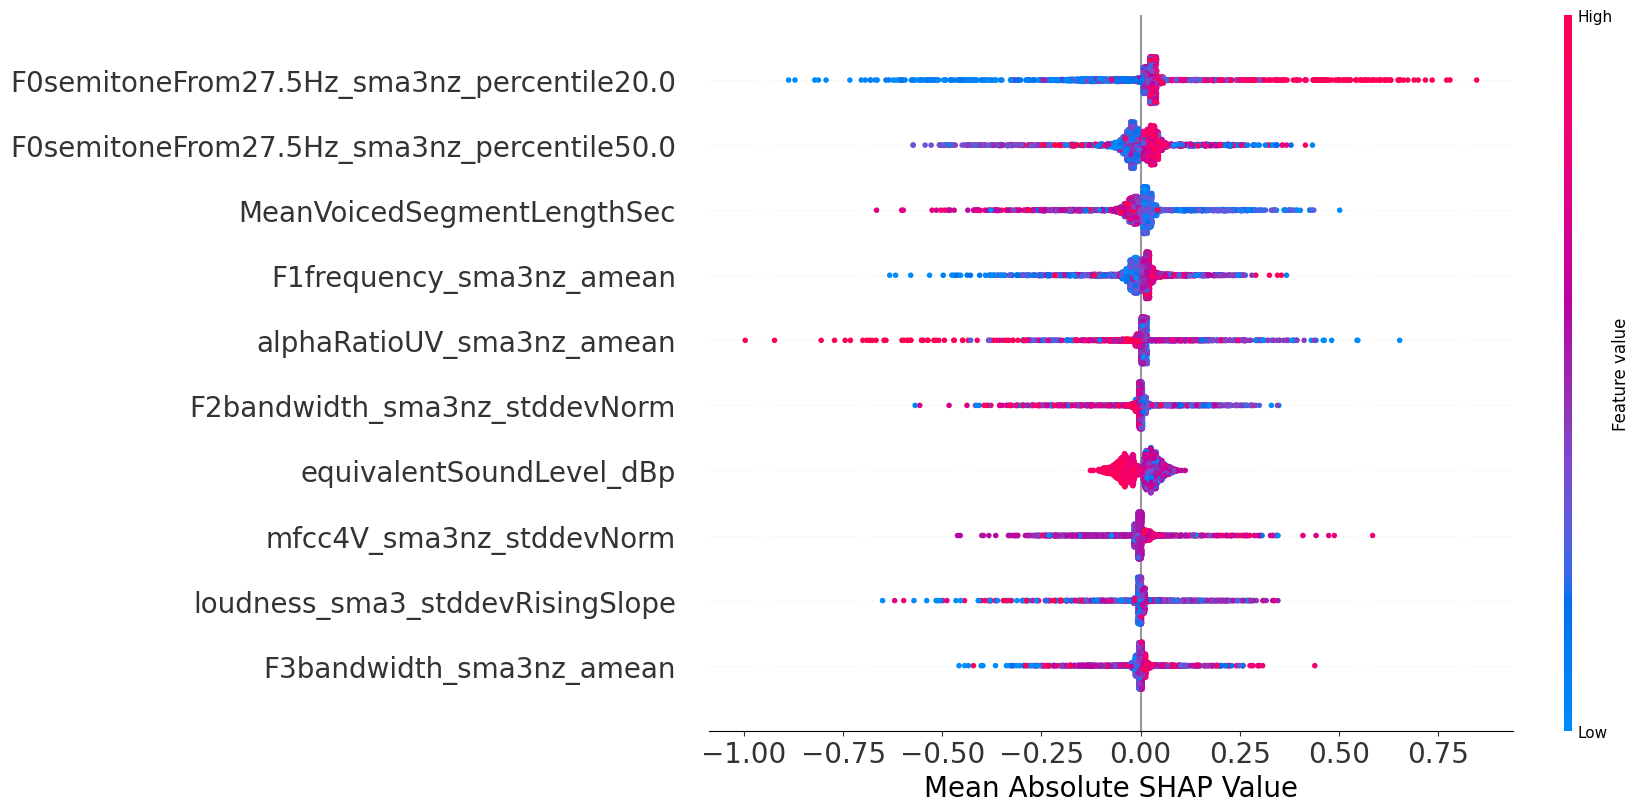

In [ ]:
# Setup experiment configurations
case_idx = -1
model_name = "XGB"
feature_selector_method = "rfe"
n_dict = {
    "n_repeats": 3,
    "outer_splits": 4,
    "inner_splits": 4,
    "n_iter": 10,
    "outer_verbose": 20,
    "inner_verbose": 1,
    "outer_n_jobs": -1,
    "inner_n_jobs": 1
}

config = create_configs(case_idx, model_name, feature_selector_method, n_dict)
out_dir = f"../results_tests/{model_name}_{feature_selector_method}/sex={config['sexes_key']}/task={config['tasks_key']}"
config.update({"out_dir": out_dir})

# Run experiment
run_experiment(config)